In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import importlib

import sys

sys.path.append("/kaggle/input/models/leonidtikhanov/pinn-model/pytorch/default/1")

import pinn_model
pinn_model = importlib.reload(pinn_model)

print(pinn_model.__file__)
print("run_experiment:", hasattr(pinn_model, "run_experiment"))

/kaggle/input/models/leonidtikhanov/pinn-model/pytorch/default/1/pinn_model.py
run_experiment: True


In [2]:
print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    device = "cuda"
    print("gpu:", torch.cuda.get_device_name(0))
else:
    device = "cpu"

print("device:", device)


torch version: 2.10.0+cu128
cuda available: True
gpu: Tesla T4
device: cuda


In [3]:
final_config = {
    "task_name": "heat1d",
    "dtype": "fp32",
    "seed": 0,
    "device": device,
    "alpha": 0.1,
    "hid_size": 64,
    "num_layers": 4,
    "n_collocation": 5000,
    "n_ic": 500,
    "n_bc": 500,
    "adam_steps": 8000,
    "lbfgs_steps": 500,
    "lr_adam": 1e-3,
    "use_adam": True,
    "use_lbfgs": True,
    "log_dir": "/kaggle/working/runs/heat1d_fp32_0",
}

In [4]:
all_summaries = []
all_histories = {}

for dtype in ["fp32", "fp64"]:
    for seed in [0, 1, 2]:
        config = final_config.copy()
        config["dtype"] = dtype
        config["seed"] = seed
        config["log_dir"] = f"/kaggle/working/runs/heat1d_{dtype}_{seed}"
        history, summary = pinn_model.run_experiment(config)
        all_summaries.append(summary)
        all_histories[f"{dtype}_seed{seed}"] = history

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


In [5]:
df = pd.DataFrame(all_summaries)
df.to_csv("results_summary.csv", index=False)
df

,task_name,dtype,seed,alpha,hid_size,num_layers,n_collocation,n_ic,n_bc,adam_steps,lbfgs_steps,final_loss,final_l2_error,time_sec,log_dir
0,heat1d,fp32,0,0.1,64,4,5000,500,500,8000,500,0.000002,0.000375,95.348943,/kaggle/working/runs/heat1d_fp32_0
1,heat1d,fp32,1,0.1,64,4,5000,500,500,8000,500,0.000001,0.000217,89.694278,/kaggle/working/runs/heat1d_fp32_1
2,heat1d,fp32,2,0.1,64,4,5000,500,500,8000,500,0.000008,0.000599,85.690834,/kaggle/working/runs/heat1d_fp32_2
3,heat1d,fp64,0,0.1,64,4,5000,500,500,8000,500,0.000007,0.000830,164.949134,/kaggle/working/runs/heat1d_fp64_0
4,heat1d,fp64,1,0.1,64,4,5000,500,500,8000,500,0.000003,0.000311,167.543627,/kaggle/working/runs/heat1d_fp64_1
5,heat1d,fp64,2,0.1,64,4,5000,500,500,8000,500,0.000002,0.000277,167.878332,/kaggle/working/runs/heat1d_fp64_2


In [6]:
grouped = df.groupby("dtype")[["final_l2_error", "final_loss", "time_sec"]].agg(["mean", "std"])
grouped.to_csv("results_grouped.csv")
grouped

final_l2_error           final_loss              time_sec          
                mean       std       mean       std        mean       std
dtype                                                                    
fp32        0.000397  0.000192   0.000004  0.000004   90.244685  4.852523
fp64        0.000473  0.000310   0.000004  0.000003  166.790364  1.603310

In [7]:
from IPython.display import display

work_dir = Path('/kaggle/working')

if 'df' not in globals():
    df = pd.read_csv(work_dir / 'results_summary.csv')

df = df.sort_values(['dtype', 'seed']).reset_index(drop=True)
display(df[['dtype', 'seed', 'final_l2_error', 'final_loss', 'time_sec', 'log_dir']])

grouped = df.groupby('dtype')[['final_l2_error', 'final_loss', 'time_sec']].agg(['mean', 'std'])
display(grouped)

best = df.loc[df['final_l2_error'].idxmin()]
display(best.to_frame('value'))

,dtype,seed,final_l2_error,final_loss,time_sec,log_dir
0,fp32,0,0.000375,0.000002,95.348943,/kaggle/working/runs/heat1d_fp32_0
1,fp32,1,0.000217,0.000001,89.694278,/kaggle/working/runs/heat1d_fp32_1
2,fp32,2,0.000599,0.000008,85.690834,/kaggle/working/runs/heat1d_fp32_2
3,fp64,0,0.000830,0.000007,164.949134,/kaggle/working/runs/heat1d_fp64_0
4,fp64,1,0.000311,0.000003,167.543627,/kaggle/working/runs/heat1d_fp64_1
5,fp64,2,0.000277,0.000002,167.878332,/kaggle/working/runs/heat1d_fp64_2


final_l2_error           final_loss              time_sec          
                mean       std       mean       std        mean       std
dtype                                                                    
fp32        0.000397  0.000192   0.000004  0.000004   90.244685  4.852523
fp64        0.000473  0.000310   0.000004  0.000003  166.790364  1.603310

,value
task_name,heat1d
dtype,fp32
seed,1
alpha,0.1
hid_size,64
num_layers,4
n_collocation,5000
n_ic,500
n_bc,500
adam_steps,8000


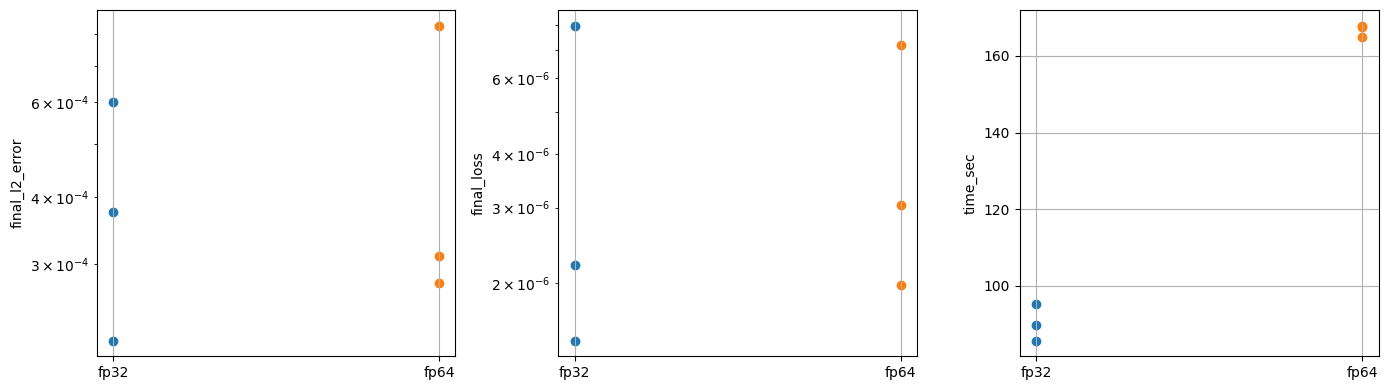

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

for i, dtype in enumerate(['fp32', 'fp64']):
    part = df[df['dtype'] == dtype]
    x = np.zeros(len(part)) + i
    ax[0].scatter(x, part['final_l2_error'])
    ax[1].scatter(x, part['final_loss'])
    ax[2].scatter(x, part['time_sec'])

names = ['fp32', 'fp64']
for a in ax:
    a.set_xticks([0, 1])
    a.set_xticklabels(names)
    a.grid(True)

ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[0].set_ylabel('final_l2_error')
ax[1].set_ylabel('final_loss')
ax[2].set_ylabel('time_sec')

fig.tight_layout()
plt.show()

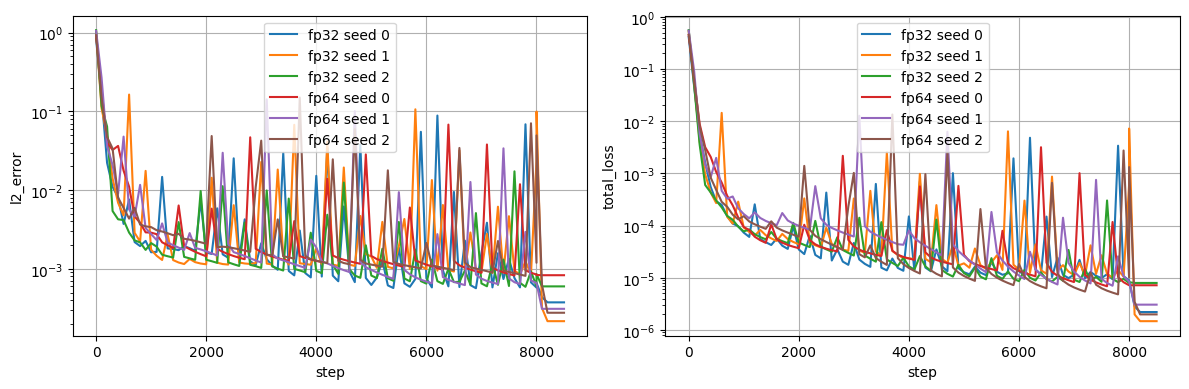

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for dtype in ['fp32', 'fp64']:
    for seed in [0, 1, 2]:
        p = work_dir / 'runs' / f'heat1d_{dtype}_{seed}' / 'metrics.csv'
        if p.exists():
            h = pd.read_csv(p)
            label = f'{dtype} seed {seed}'
            ax[0].plot(h['step'], h['l2_error'], label=label)
            ax[1].plot(h['step'], h['total_loss'], label=label)

ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('step')
ax[1].set_xlabel('step')
ax[0].set_ylabel('l2_error')
ax[1].set_ylabel('total_loss')
ax[0].grid(True)
ax[1].grid(True)
ax[0].legend()
ax[1].legend()

fig.tight_layout()
plt.show()

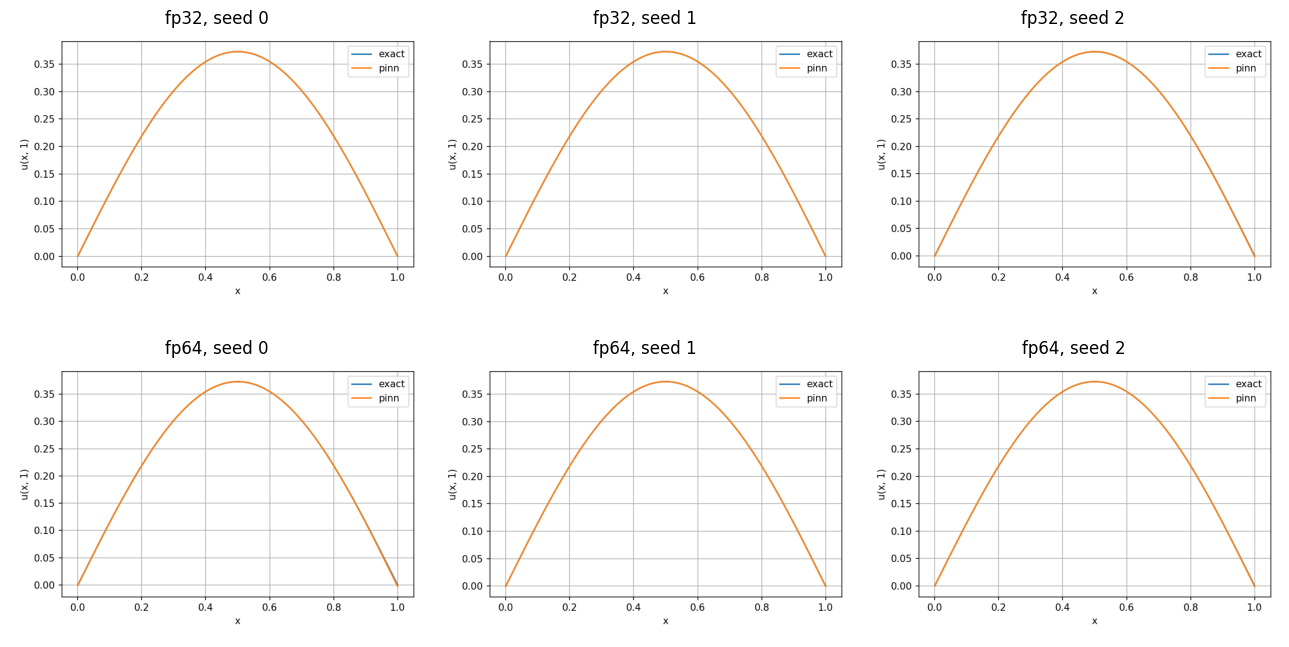

In [10]:
fig, ax = plt.subplots(2, 3, figsize=(13, 7))

for i, dtype in enumerate(['fp32', 'fp64']):
    for j, seed in enumerate([0, 1, 2]):
        p = work_dir / 'runs' / f'heat1d_{dtype}_{seed}' / 'solution_t1.png'
        ax[i, j].set_title(f'{dtype}, seed {seed}')
        ax[i, j].axis('off')
        if p.exists():
            img = plt.imread(p)
            ax[i, j].imshow(img)

fig.tight_layout()
plt.show()